# Fig 7.7

model of lac operon in E. coli

In [1]:
using Catalyst
using ModelingToolkit
using OrdinaryDiffEq
using SteadyStateDiffEq
using Plots
Plots.default(linewidth=2)

In [2]:
rn = @reaction_network begin
    @parameters Le(t)
    a1 / (1 + RToverK1 * (K2 / (K2 + L))^4), 0 --> M
    δM, M --> 0
    (c1 * M, δY), 0 <--> Y
    mm(Le, kL * Y, KML), 0 --> L
    mm(L, 2 * kg * (Y / 4), KMg), L => 0
    δL, L --> 0
end

Model ##ReactionSystem#265:
Unknowns (3): see unknowns(##ReactionSystem#265)
  M(t)
  Y(t)
  L(t)
Parameters (12): see parameters(##ReactionSystem#265)
  Le(t)
  a1
  RToverK1
  K2
  ⋮

In [3]:
setdefaults!(rn, [
    :δM => 0.48,
    :δY => 0.03,
    :δL => 0.02,
    :a1 => 0.29,
    :K2 => 2.92 * 1e6,
    :RToverK1 => 213.2,
    :c1 => 18.8,
    :kL => 6 * 1e4,
    :KML => 680,
    :kg => 3.6 * 1e3,
    :KMg => 7 * 1e5,
    :Le => 0.0,
    :M => 0.01,
    :Y => 0.1,
    :L => 0.0
])

@unpack Le = rn
discrete_events = [[500.0] => [Le ~ 50], [1000.0] => [Le ~ 100], [1500.0] => [Le ~ 150], [2000.0] => [Le ~ 0]]
osys = convert(ODESystem, rn; discrete_events, remove_conserved=true) |> structural_simplify

┌ Warning: You are creating a system or problem while eliminating conserved quantities. Please note,
│         due to limitations / design choices in ModelingToolkit if you use the created system to
│         create a problem (e.g. an `ODEProblem`), or are directly creating a problem, you *should not*
│         modify that problem's initial conditions for species (e.g. using `remake`). Changing initial
│         conditions must be done by creating a new Problem from your reaction system or the
│         ModelingToolkit system you converted it into with the new initial condition map.
│         Modification of parameter values is still possible, *except* for the modification of any
│         conservation law constants (Γ), which is not possible. You might
│         get this warning when creating a problem directly.
│ 
│         You can remove this warning by setting `remove_conserved_warn = false`.
└ @ Catalyst ~/.julia/packages/Catalyst/48wH3/src/reactionsystem_conversions.jl:456


Model ##ReactionSystem#265:
Equations (3):
  3 standard: see equations(##ReactionSystem#265)
Unknowns (3): see unknowns(##ReactionSystem#265)
  M(t) [defaults to 0.01]
  Y(t) [defaults to 0.1]
  L(t) [defaults to 0.0]
Parameters (12): see parameters(##ReactionSystem#265)
  δY [defaults to 0.03]
  δM [defaults to 0.48]
  kL [defaults to 60000.0]
  KMg [defaults to 700000.0]
  ⋮

## Fig 7.07 (A)

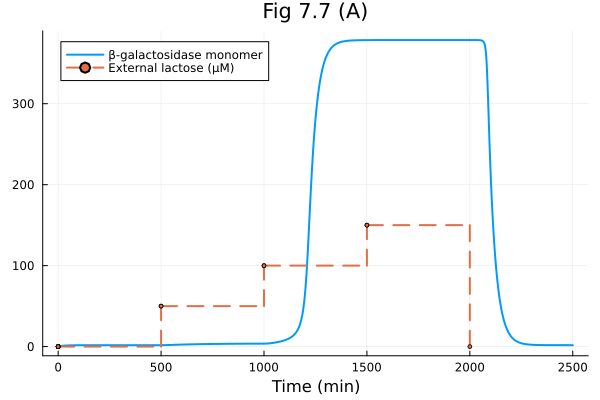

In [4]:
tend = 2500.0
prob = ODEProblem(osys, [], tend)
sol = solve(prob)

@unpack M, Y, L, Le = osys
plot(sol, idxs=[Y, Le], xlabel="Time (min)", title="Fig 7.7 (A)", label=["β-galactosidase monomer" "External lactose (μM)"])

## Fig 7.07 (B)
Compare the original model and the modified model

In [5]:
rn_mod = @reaction_network begin
    @parameters Le(t)
    a1 / (1 + RToverK1 * (K2 / (K2 + L))^4), 0 --> M
    δM, M --> 0
    (c1 * M, δY), 0 <--> Y
    mm(Le, kL * 4 * Enz, KML), 0 --> L
    mm(L, 2 * kg * Enz, KMg), L ⇒ 0
    δL, L --> 0
end

Model ##ReactionSystem#279:
Unknowns (3): see unknowns(##ReactionSystem#279)
  M(t)
  Y(t)
  L(t)
Parameters (13): see parameters(##ReactionSystem#279)
  Le(t)
  a1
  RToverK1
  K2
  ⋮

In [6]:
setdefaults!(rn_mod, [
    :δM => 0.48,
    :δY => 0.03,
    :δL => 0.02,
    :a1 => 0.29,
    :K2 => 2.92 * 1e6,
    :RToverK1 => 213.2,
    :c1 => 18.8,
    :kL => 6 * 1e4,
    :KML => 680,
    :kg => 3.6 * 1e3,
    :KMg => 7 * 1e5,
    :Le => 0.0,
    :M => 0.01,
    :Y => 0.1,
    :L => 0.0,
    :Enz => 40.0
])

osys_mod = convert(ODESystem, rn_mod; remove_conserved=true) |> structural_simplify

┌ Warning: You are creating a system or problem while eliminating conserved quantities. Please note,
│         due to limitations / design choices in ModelingToolkit if you use the created system to
│         create a problem (e.g. an `ODEProblem`), or are directly creating a problem, you *should not*
│         modify that problem's initial conditions for species (e.g. using `remake`). Changing initial
│         conditions must be done by creating a new Problem from your reaction system or the
│         ModelingToolkit system you converted it into with the new initial condition map.
│         Modification of parameter values is still possible, *except* for the modification of any
│         conservation law constants (Γ), which is not possible. You might
│         get this warning when creating a problem directly.
│ 
│         You can remove this warning by setting `remove_conserved_warn = false`.
└ @ Catalyst ~/.julia/packages/Catalyst/48wH3/src/reactionsystem_conversions.jl:456


Model ##ReactionSystem#279:
Equations (3):
  3 standard: see equations(##ReactionSystem#279)
Unknowns (3): see unknowns(##ReactionSystem#279)
  M(t) [defaults to 0.01]
  Y(t) [defaults to 0.1]
  L(t) [defaults to 0.0]
Parameters (13): see parameters(##ReactionSystem#279)
  δY [defaults to 0.03]
  δM [defaults to 0.48]
  Enz [defaults to 40.0]
  kL [defaults to 60000.0]
  ⋮

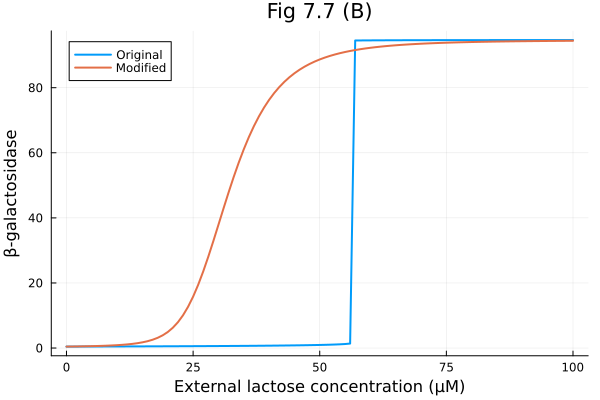

In [7]:
prob = SteadyStateProblem(rn, [])
prob_mod = SteadyStateProblem(rn_mod, [])

@unpack Le, Y = osys
lerange = range(0, 100, 101)

eprob = EnsembleProblem(prob;
    prob_func=(prob, i, repeat) -> remake(prob, p=[Le=>lerange[i]]),
    output_func=(sol, i) -> (sol[Y] / 4, false)
)

eprob_mod = EnsembleProblem(prob_mod;
    prob_func=(prob, i, repeat) -> remake(prob, p=[Le=>lerange[i]]),
    output_func=(sol, i) -> (sol[Y] / 4, false)
)

sim = solve(eprob, DynamicSS(Rodas5()); trajectories=length(lerange), abstol=1e-9, reltol=1e-9)
sim_mod = solve(eprob_mod, DynamicSS(Rodas5()); trajectories=length(lerange), abstol=1e-9, reltol=1e-9)

fig = plot(lerange, sim.u, label="Original")
fig = plot!(fig, lerange, sim_mod.u, label="Modified")
fig = plot!(fig,
    xlabel="External lactose concentration (μM)",
    ylabel="β-galactosidase",
    title="Fig 7.7 (B)"
)

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*